In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

# Import Model
from models.AutoEncoder.AutoEncoder_a import AE

# Import utils
from utils.train_val_ae_utils import train_and_evaluate_ae
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_ae_utils import load_best_model_ae
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


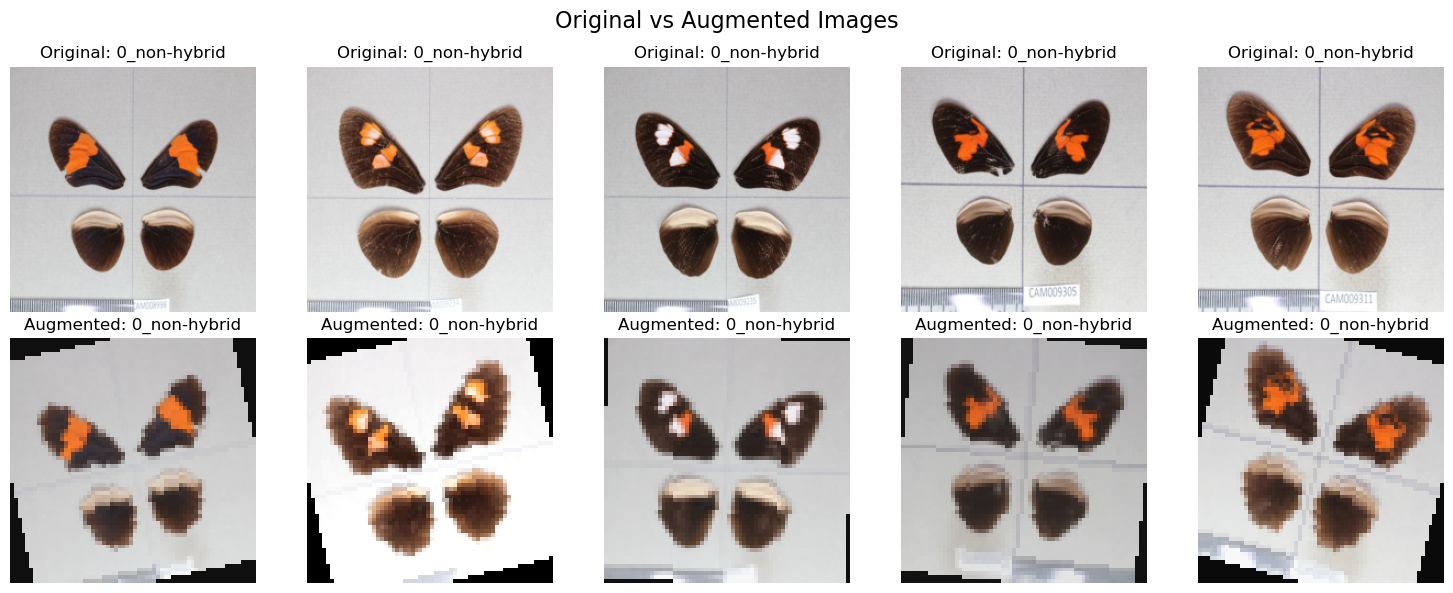

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [5]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
batch_size_values = [16, 32, 64, 128]

model_ae_a_dict = {}
optimzer_a_dict = {}
results_a_dict = {}
best_a_dict = {}
best_f2_a_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_batch_size_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_batch_size = 16

best_f2 = float("-inf")

# prepare non hybrid indices for training the autoencoder on only normal samples
non_hybrid_idx = train_dataset_aug.class_to_idx["0_non-hybrid"]
normal_indices = [i for i, y in enumerate(train_dataset_aug.targets) if y == non_hybrid_idx]

# hyperparameter tuning for learning rate
for learning_rate in learning_rate_values:
    model_ae_a_dict[f"model_ae_a{count}"] = AE().to(device)
    optimzer_a_dict[f"optimizer_a{count}"] = optim.Adam(
        model_ae_a_dict[f"model_ae_a{count}"].parameters(),
        lr=learning_rate,
        weight_decay=best_weight_decay,
    )
    criterion = nn.MSELoss()

    train_loader_ae = DataLoader(Subset(train_dataset_aug, normal_indices), batch_size=best_batch_size, shuffle=True, num_workers=0)
    val_loader_ae = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0)

    ckpt_file = f"../../saved_models/ae/ae_a/ae_model_a{count}_log.pkl"
    print(f"\nTraining AutoEncoder Model A{count} with learning rate {learning_rate}")
    train_and_evaluate_ae(
        model=model_ae_a_dict[f"model_ae_a{count}"],
        train_loader=train_loader_ae,
        val_loader=val_loader_ae,
        optimizer=optimzer_a_dict[f"optimizer_a{count}"],
        criterion=criterion,
        num_epochs=30,
        ckpt_file=ckpt_file,
        device=device,
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
    )

    results_a_dict[f"results_a{count}"] = results_from_ckpt(model_ae_a_dict[f"model_ae_a{count}"], ckpt_file=ckpt_file)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_ae_a_dict[f"model_ae_a{count}"], ckpt_file=ckpt_file)
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = best_weight_decay
    best_batch_size_dict[f"best_batch_size_a{count}"] = best_batch_size

    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]

# hyperparameter tuning for weight decay
for weight_decay in weight_decay_values[1:]:
    model_ae_a_dict[f"model_ae_a{count}"] = AE().to(device)
    optimzer_a_dict[f"optimizer_a{count}"] = optim.Adam(
        model_ae_a_dict[f"model_ae_a{count}"].parameters(),
        lr=best_learning_rate,
        weight_decay=weight_decay,
    )
    criterion = nn.MSELoss()

    train_loader_ae = DataLoader(Subset(train_dataset_aug, normal_indices), batch_size=best_batch_size, shuffle=True, num_workers=0)
    val_loader_ae = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0)

    ckpt_file = f"../../saved_models/ae/ae_a/ae_model_a{count}_log.pkl"
    print(f"\nTraining AutoEncoder Model A{count} with weight decay {weight_decay}")
    train_and_evaluate_ae(
        model=model_ae_a_dict[f"model_ae_a{count}"],
        train_loader=train_loader_ae,
        val_loader=val_loader_ae,
        optimizer=optimzer_a_dict[f"optimizer_a{count}"],
        criterion=criterion,
        num_epochs=30,
        ckpt_file=ckpt_file,
        device=device,
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
    )

    results_a_dict[f"results_a{count}"] = results_from_ckpt(model_ae_a_dict[f"model_ae_a{count}"], ckpt_file=ckpt_file)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_ae_a_dict[f"model_ae_a{count}"], ckpt_file=ckpt_file)
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = weight_decay
    best_batch_size_dict[f"best_batch_size_a{count}"] = best_batch_size

    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]

# hyperparameter tuning for batch size
for batch_size in batch_size_values[1:]:
    model_ae_a_dict[f"model_ae_a{count}"] = AE().to(device)
    optimzer_a_dict[f"optimizer_a{count}"] = optim.Adam(
        model_ae_a_dict[f"model_ae_a{count}"].parameters(),
        lr=best_learning_rate,
        weight_decay=best_weight_decay,
    )
    criterion = nn.MSELoss()

    train_loader_ae = DataLoader(Subset(train_dataset_aug, normal_indices), batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader_ae = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    ckpt_file = f"../../saved_models/ae/ae_a/ae_model_a{count}_log.pkl"
    print(f"\nTraining AutoEncoder Model A{count} with batch size {batch_size}")
    train_and_evaluate_ae(
        model=model_ae_a_dict[f"model_ae_a{count}"],
        train_loader=train_loader_ae,
        val_loader=val_loader_ae,
        optimizer=optimzer_a_dict[f"optimizer_a{count}"],
        criterion=criterion,
        num_epochs=30,
        ckpt_file=ckpt_file,
        device=device,
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
    )

    results_a_dict[f"results_a{count}"] = results_from_ckpt(model_ae_a_dict[f"model_ae_a{count}"], ckpt_file=ckpt_file)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_ae_a_dict[f"model_ae_a{count}"], ckpt_file=ckpt_file)
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = best_weight_decay
    best_batch_size_dict[f"best_batch_size_a{count}"] = batch_size

    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]


Training AutoEncoder Model A1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.644531
  [Epoch 2] Improvement! New best score: 0.664557
Epoch [5/30], Train Loss: 0.1750, Val Loss: 0.1480, Train F1-Macro: 0.1582, Val F1-Macro: 0.6039, Train F1-Per-Class: [0.31632945 0.        ], Val F1-Per-Class: [0.7445743 0.4631579], Train F2-Macro: 0.1122, Val F2-Macro: 0.6542, Train F2-Per-Class: [0.22431493 0.        ], Val F2-Per-Class: [0.6535756 0.6547619], No improvement: 3/6

Early stopping at epoch 8. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.664557)
Selected epoch: 2
Best val F2(class 0): 0.7200461030006409
Best val F2(class 1): 0.6645569801330566

Training AutoEncoder Model A2 with learning rate 0.005
  [Epoch 1] Improvement! New best score: 0.602190
  [Epoch 2] Improvement! New best score: 0.639535
  [Epoch 4] Improvement! New best score: 0.648148
Epoch [5/30], Train Loss: 0.1751, Val Loss: 0.1514, Train F1-Macro: 0.1448, Val F1-Macro:

In [7]:
# Restore best hyperparameters for model_a
best_learning_rate_dict = {'best_learning_rate_a1': 0.01, 'best_learning_rate_a2': 0.005, 'best_learning_rate_a3': 0.001, 'best_learning_rate_a4': 0.0001, 'best_learning_rate_a5': 0.01, 'best_learning_rate_a6': 0.01, 'best_learning_rate_a7': 0.01, 'best_learning_rate_a8': 0.01, 'best_learning_rate_a9': 0.01, 'best_learning_rate_a10': 0.01}
best_weight_decay_dict = {'best_weight_decay_a1': 0.001, 'best_weight_decay_a2': 0.001, 'best_weight_decay_a3': 0.001, 'best_weight_decay_a4': 0.001, 'best_weight_decay_a5': 0.0001, 'best_weight_decay_a6': 1e-05, 'best_weight_decay_a7': 1e-06, 'best_weight_decay_a8': 0.001, 'best_weight_decay_a9': 0.001, 'best_weight_decay_a10': 0.001}
best_batch_size_dict = {'best_batch_size_a1': 16, 'best_batch_size_a2': 16, 'best_batch_size_a3': 16, 'best_batch_size_a4': 16, 'best_batch_size_a5': 16, 'best_batch_size_a6': 16, 'best_batch_size_a7': 16, 'best_batch_size_a8': 32, 'best_batch_size_a9': 64, 'best_batch_size_a10': 128}

# Initialize model_ae_a_dict with AE instances for each hyperparameter combination
model_ae_a_dict = {
    f"model_ae_a{i}": AE().to(device)
    for i in range(1, 11)
}

best_a_dict = {}
best_f2_a_dict = {}

In [8]:
for i in range(1, 6):
    print(
        f"Model A{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_a{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_a{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_a{i}']}"
    )
    best_a_dict[f"best_a{i}"], best_f2_a_dict[f"best_f2_a{i}"] = show_best_model(model=model_ae_a_dict[f"model_ae_a{i}"], ckpt_file=f"../../saved_models/ae/ae_a/ae_model_a{i}_log.pkl")

Model A1 | lr=0.01 | wd=0.001 | bs=16
Selected epoch: 2
Best val F2(class 0): 0.7200461030006409
Best val F2(class 1): 0.6645569801330566
Model A2 | lr=0.005 | wd=0.001 | bs=16
Selected epoch: 18
Best val F2(class 0): 0.6688084006309509
Best val F2(class 1): 0.6626505851745605
Model A3 | lr=0.001 | wd=0.001 | bs=16
Selected epoch: 11
Best val F2(class 0): 0.6637426614761353
Best val F2(class 1): 0.6600000262260437
Model A4 | lr=0.0001 | wd=0.001 | bs=16
Selected epoch: 1
Best val F2(class 0): 0.6356680393218994
Best val F2(class 1): 0.645792543888092
Model A5 | lr=0.01 | wd=0.0001 | bs=16
Selected epoch: 1
Best val F2(class 0): 0.6246317028999329
Best val F2(class 1): 0.623781681060791


In [9]:
for i in range(6, 11):
    print(
        f"Model A{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_a{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_a{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_a{i}']}"
    )
    best_a_dict[f"best_a{i}"], best_f2_a_dict[f"best_f2_a{i}"] = show_best_model(model=model_ae_a_dict[f"model_ae_a{i}"], ckpt_file=f"../../saved_models/ae/ae_a/ae_model_a{i}_log.pkl")

Model A6 | lr=0.01 | wd=1e-05 | bs=16
Selected epoch: 3
Best val F2(class 0): 0.5685218572616577
Best val F2(class 1): 0.630797803401947
Model A7 | lr=0.01 | wd=1e-06 | bs=16
Selected epoch: 2
Best val F2(class 0): 0.6027315855026245
Best val F2(class 1): 0.6463878154754639
Model A8 | lr=0.01 | wd=0.001 | bs=32
Selected epoch: 8
Best val F2(class 0): 0.6688084006309509
Best val F2(class 1): 0.6626505851745605
Model A9 | lr=0.01 | wd=0.001 | bs=64
Selected epoch: 8
Best val F2(class 0): 0.6637426614761353
Best val F2(class 1): 0.6600000262260437
Model A10 | lr=0.01 | wd=0.001 | bs=128
Selected epoch: 8
Best val F2(class 0): 0.6612054109573364
Best val F2(class 1): 0.658682644367218


In [10]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_a_dict, key=lambda k: float(best_f2_a_dict[k]))
best_i = int(best_f2_key.split("a")[-1])

model = model_ae_a_dict[f"model_ae_a{best_i}"]
best = best_a_dict[f"best_a{best_i}"]

print(
    f"Selected Best Model A{best_i} | "
    f"val_f2_class1={float(best_f2_a_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_a{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_a{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_a{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model_ae(
        best_model=model,
        best=best,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        device=device,
        batch_size=best_batch_size_dict[f'best_batch_size_a{i}'],
        num_workers=2,
        beta=2.0,
)

Selected Best Model A1 | val_f2_class1=0.664557 | lr=0.01 | wd=0.001 | bs=16
Test loss: 0.06134185225174234
Test F2 macro: 0.643059253692627
Test F2 per class: [0.70034444 0.58577406]
Test F2 for class 1 (1_hybrid): 0.5857740640640259


{'threshold': 0.062119682820943684,
 'val_f2': 0.6645569801330566,
 'test_loss': 0.06134185225174234,
 'test_f2_macro': 0.643059253692627,
 'test_f2_per_class': array([0.70034444, 0.58577406], dtype=float32),
 'test_f2': 0.5857740640640259}

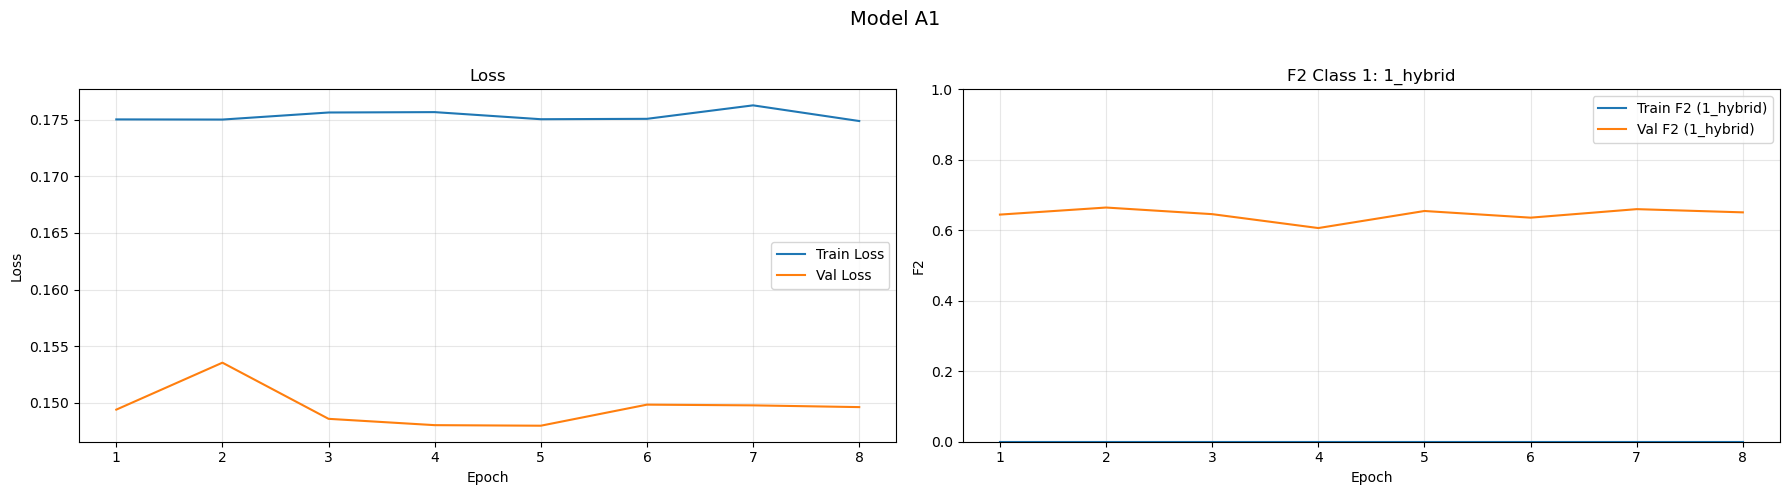

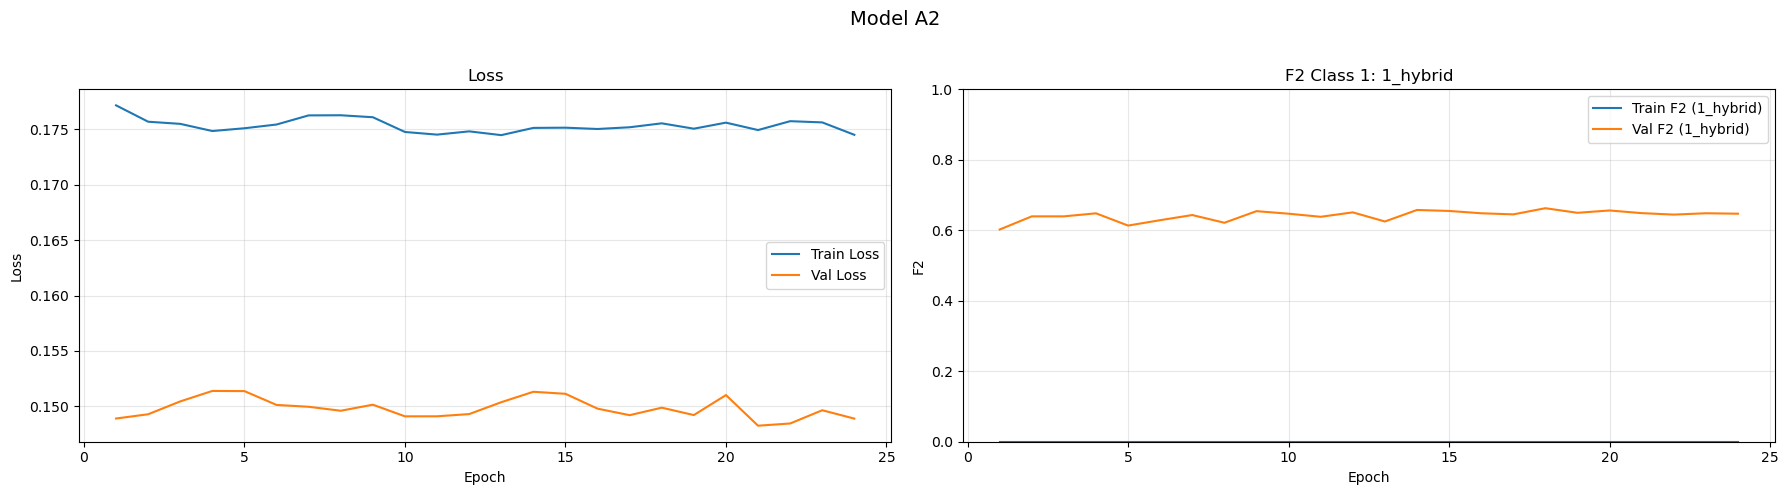

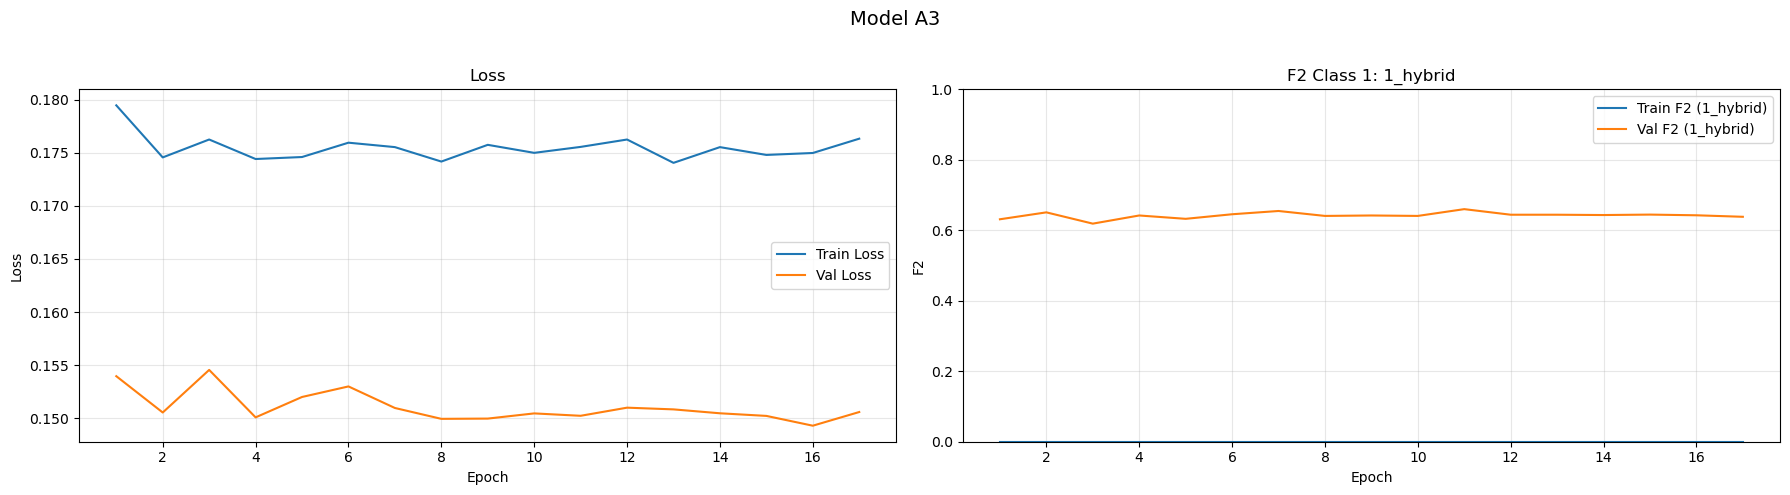

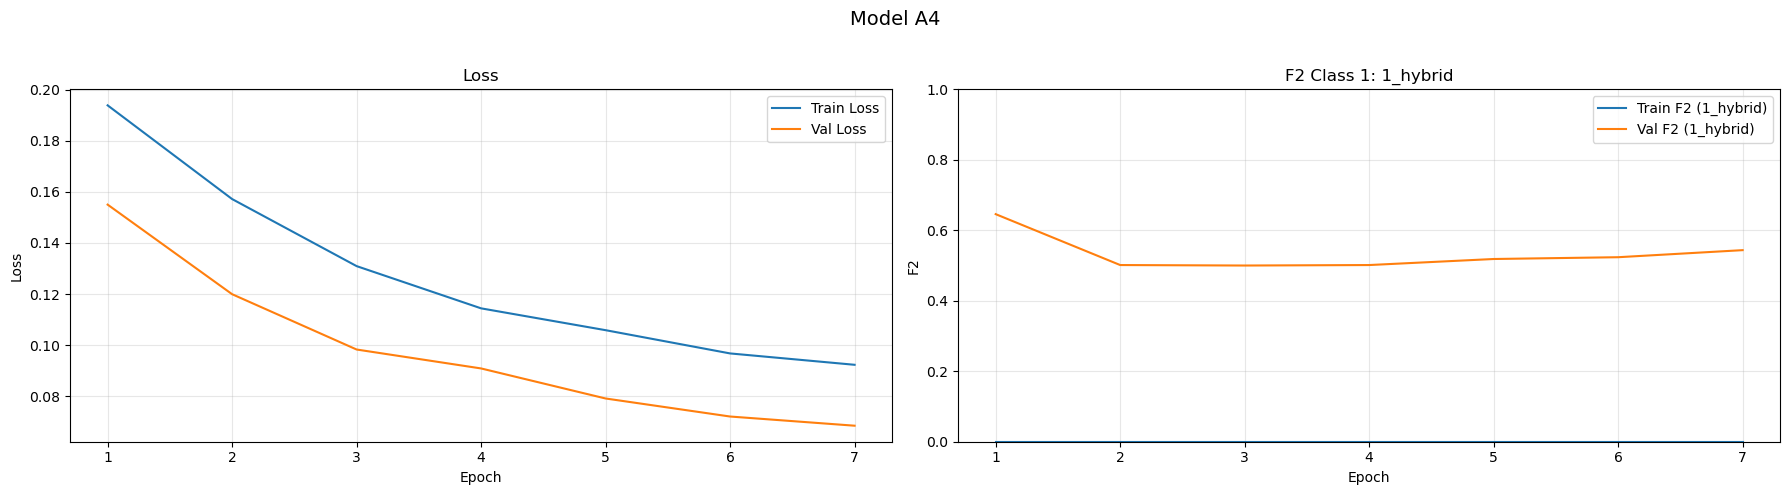

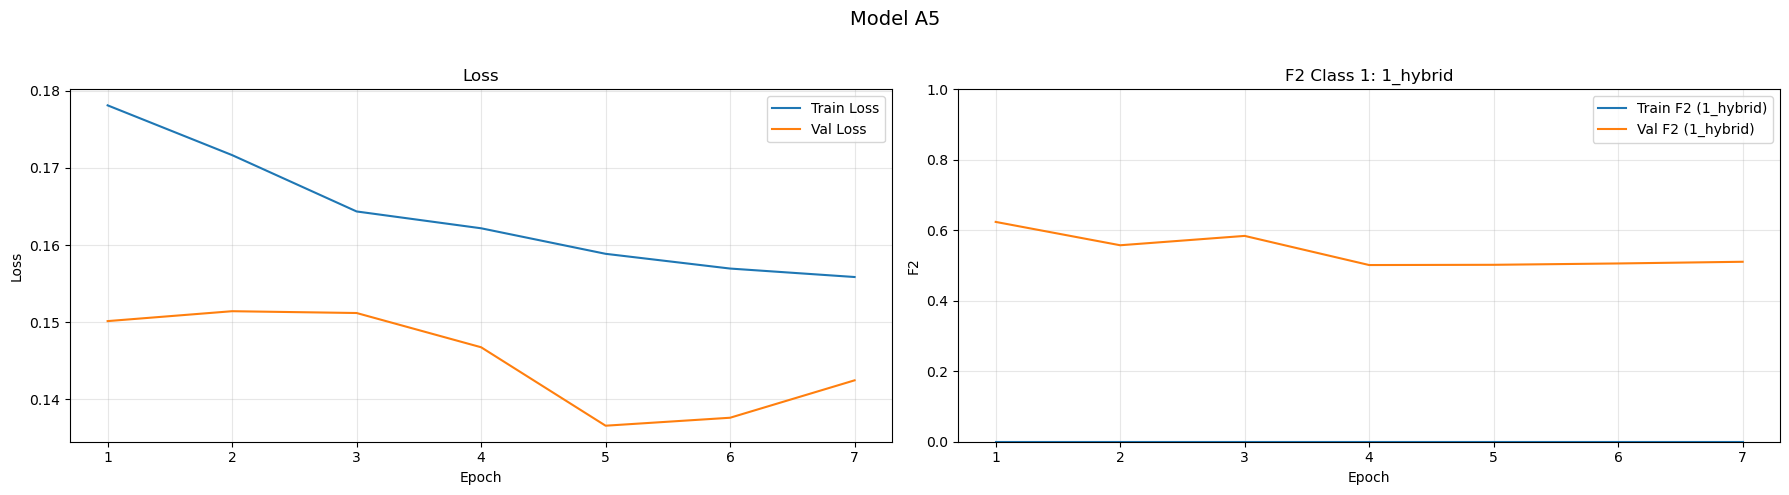

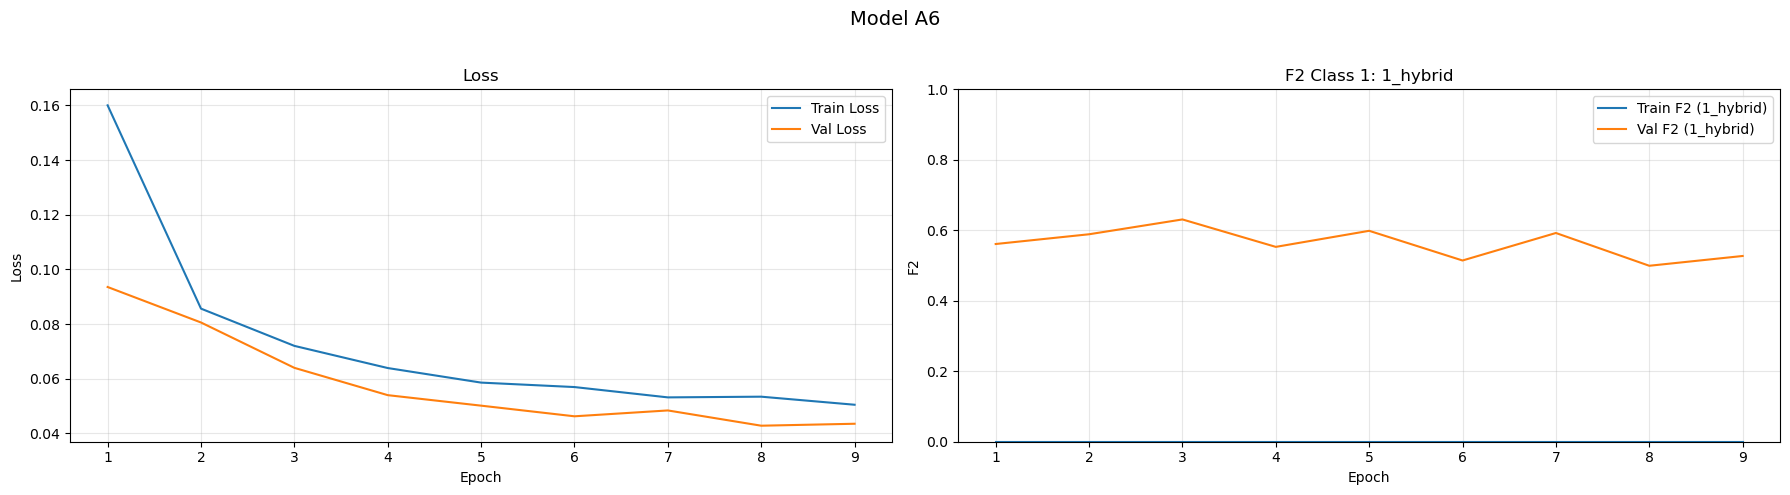

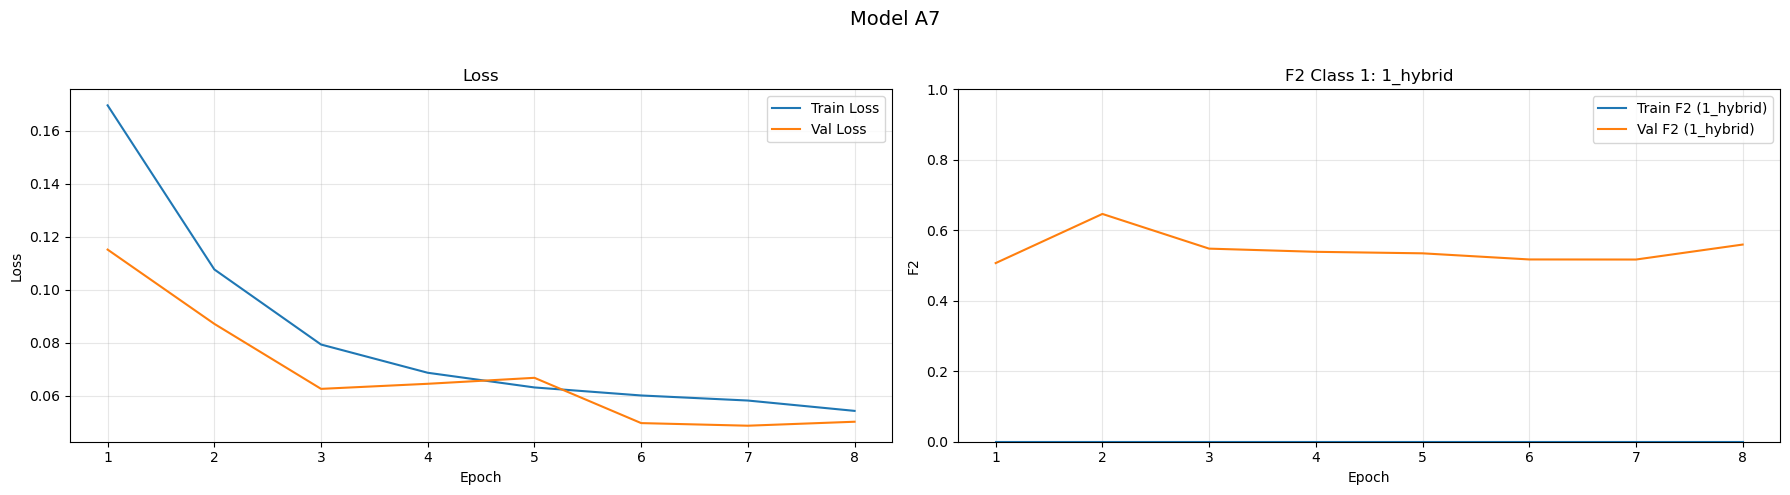

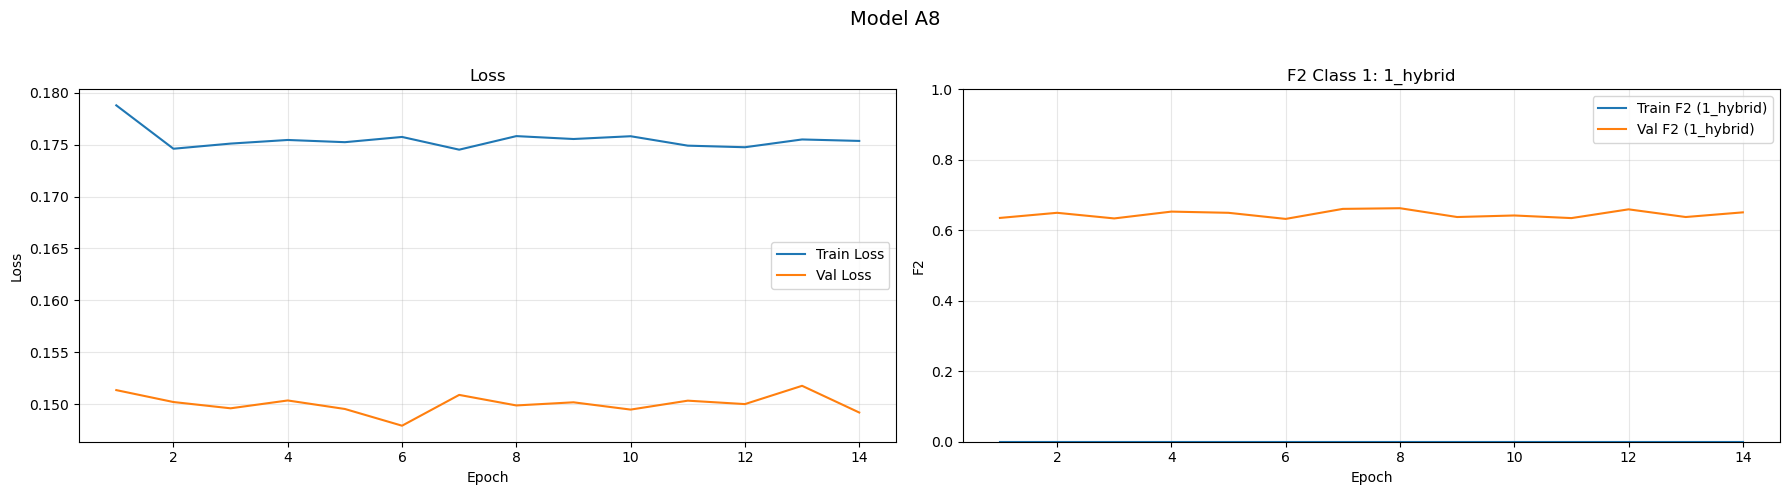

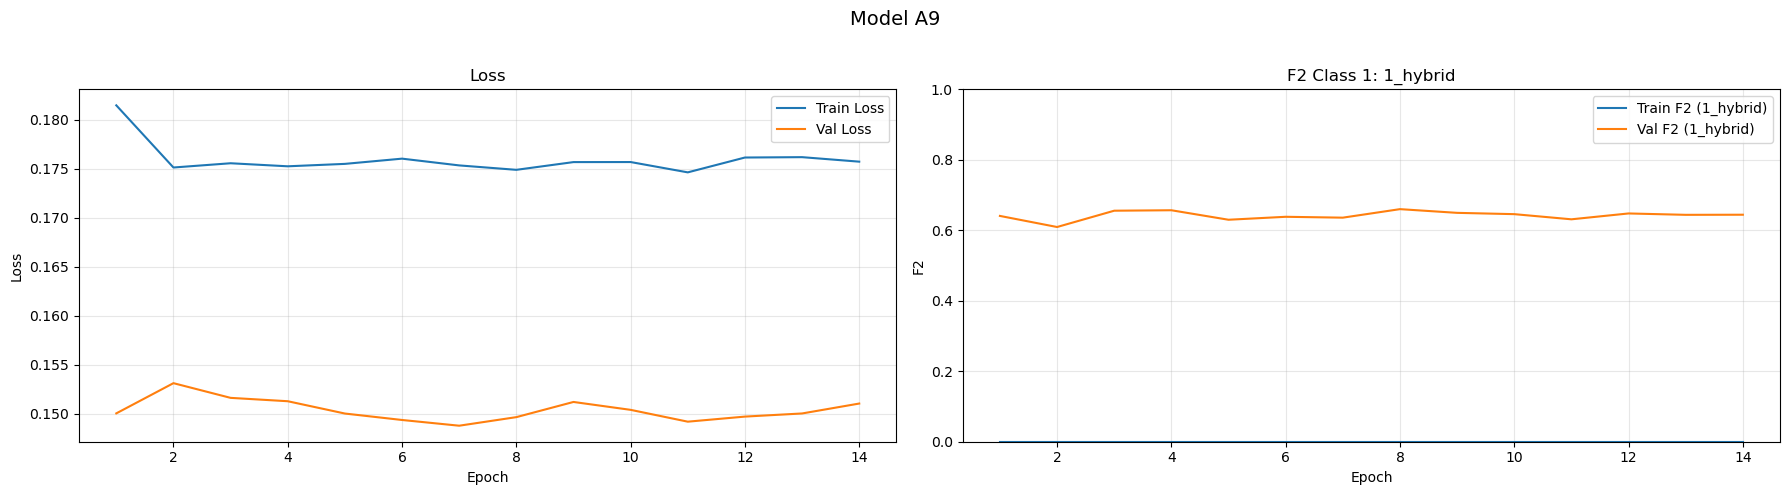

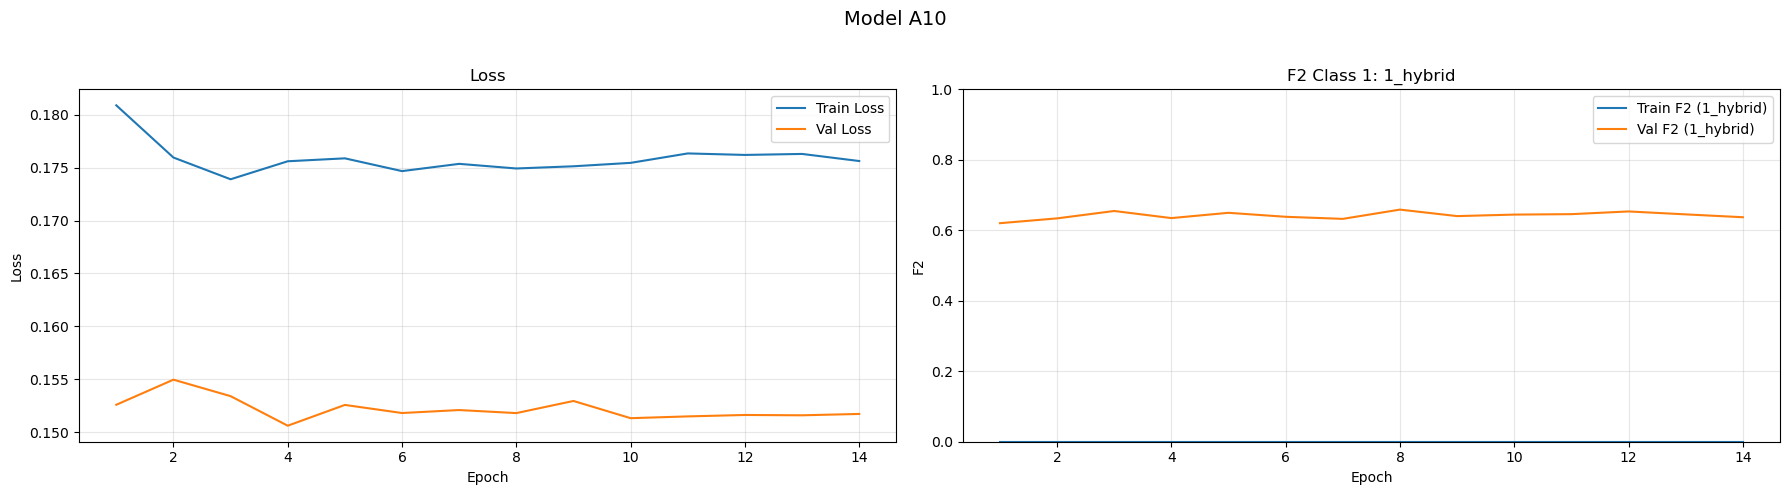

In [13]:
for i in range(1, 11):
    plot_training_curves(
        model_name=f"Model A{i}",
        results = results_from_ckpt(
            model=model_ae_a_dict[f"model_ae_a{i}"],
            ckpt_file=f"../../saved_models/ae/ae_a/ae_model_a{i}_log.pkl"
        ),
        class_idx=1,
        class_name="1_hybrid"
    )